#Árboles de decisión sobre el conjunto de subespecies de flor iris

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve, LearningCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

## 1. Carga y limpieza de datos

In [ ]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

## Limpieza

In [ ]:
df = df.drop_duplicates()
print(f"Datos finales: {df.shape}")

Datos finales: (149, 5)


## 2. Preprocesamiento

In [ ]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

### División de datos

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


### Escalado (usando solo datos de entrenamiento)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Optimización de hiperparámetros


In [ ]:
param_grid = {
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor precisión CV: {grid_search.best_score_:.2f}")


Mejores parámetros: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2}
Mejor precisión CV: 0.95


## 4. Evaluación

In [ ]:
y_pred = best_model.predict(X_test_scaled)
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Matriz de confusión con datos de prueba

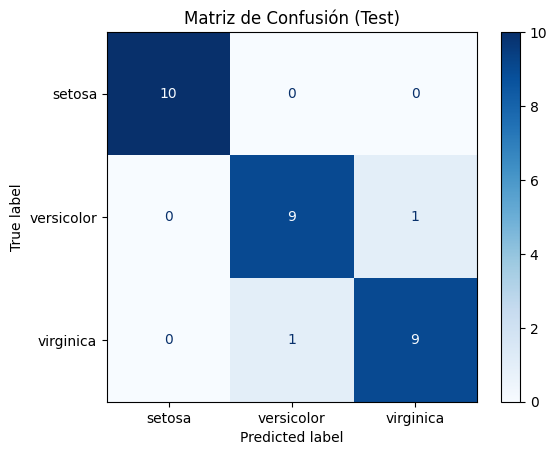

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión (Test)")
plt.show()

## 5. Visualizaciones mejoradas
### Árbol de decisión

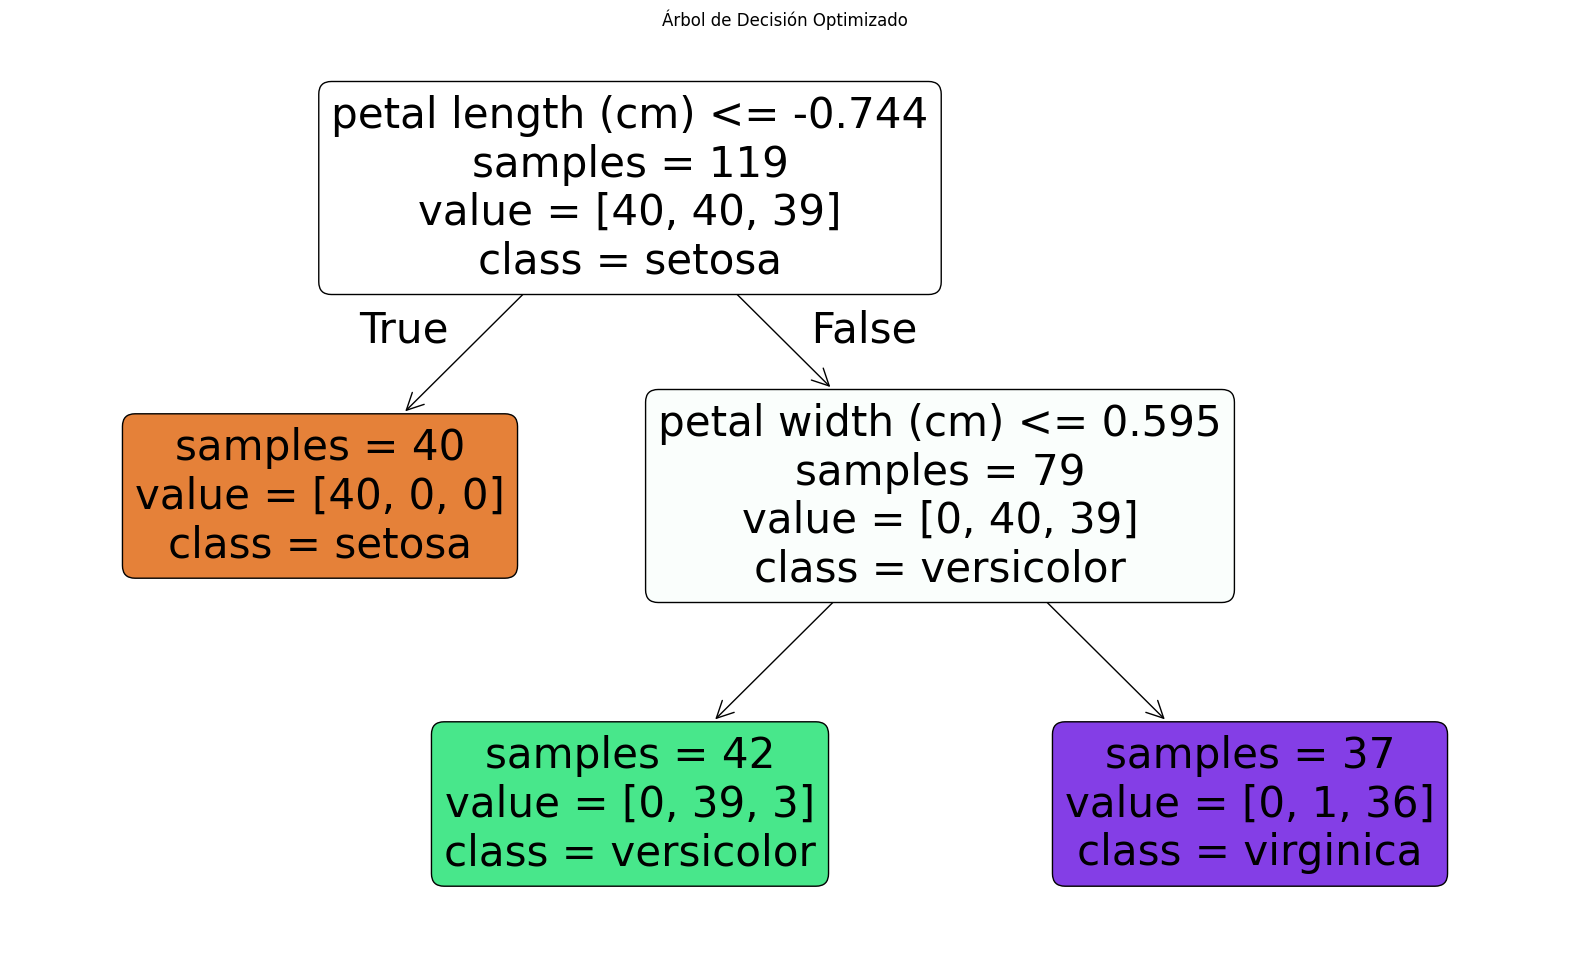

In [ ]:
plt.figure(figsize=(20, 12))
plot_tree(best_model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          impurity=False)
plt.title("Árbol de Decisión Optimizado")
plt.show()


### Curvas de validación y aprendizaje

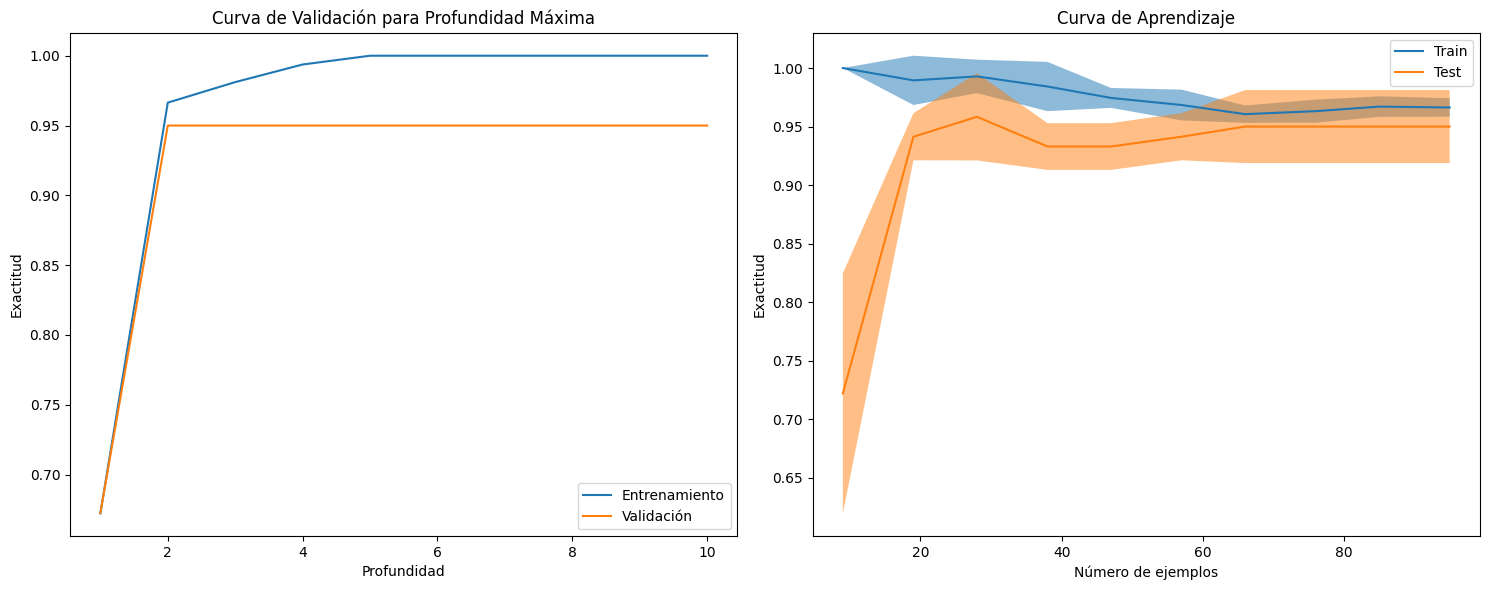

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

param_range = np.arange(1, 11)
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train_scaled,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5
)

ax[0].plot(param_range, np.mean(train_scores, axis=1), label="Entrenamiento")
ax[0].plot(param_range, np.mean(test_scores, axis=1), label="Validación")
ax[0].set_title("Curva de Validación para Profundidad Máxima")
ax[0].set_xlabel("Profundidad")
ax[0].set_ylabel("Exactitud")
ax[0].legend()

### Curva de aprendizaje
LearningCurveDisplay.from_estimator(
    best_model, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    ax=ax[1],
    scoring='accuracy'
)
ax[1].set_title("Curva de Aprendizaje")
ax[1].set_ylabel("Exactitud")
ax[1].set_xlabel("Número de ejemplos")
plt.tight_layout()
plt.show()

## 6. Visualización 2D con datos de entrenamiento y prueba

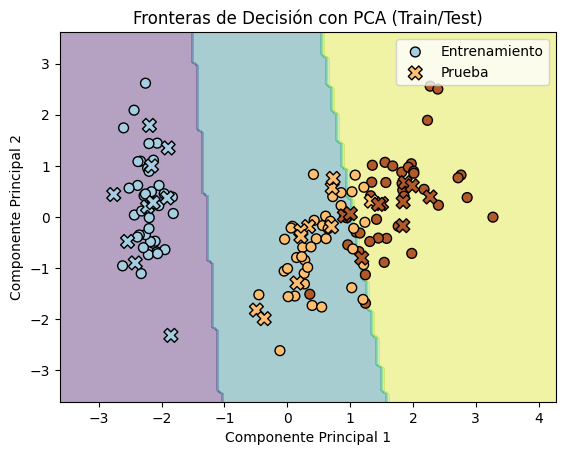

In [ ]:
def plot_decision_boundaries(X_train, X_test, y_train, y_test, model, title):
    # Aplicar PCA solo a los datos de entrenamiento
    pca = PCA(n_components=2).fit(X_train)

    # Transformar ambos conjuntos
    X_train_pca = pca.transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Crear malla
    x_min, x_max = X_train[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Invertir PCA y predecir
    Z = model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)

    # Plot
    plt.contourf(xx, yy, Z, alpha=0.4)
    # Datos de entrenamiento (círculos)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train,
                edgecolor='k', s=50, cmap='Paired', label="Entrenamiento")
    # Datos de prueba (X)
    plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test,
                marker='X', s=100, edgecolor='k', cmap='Paired', label="Prueba")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundaries(X_train_scaled, X_test_scaled, y_train, y_test,
                        best_model, "Fronteras de Decisión con PCA (Train/Test)")


## 7. Visualización 3D con LDA


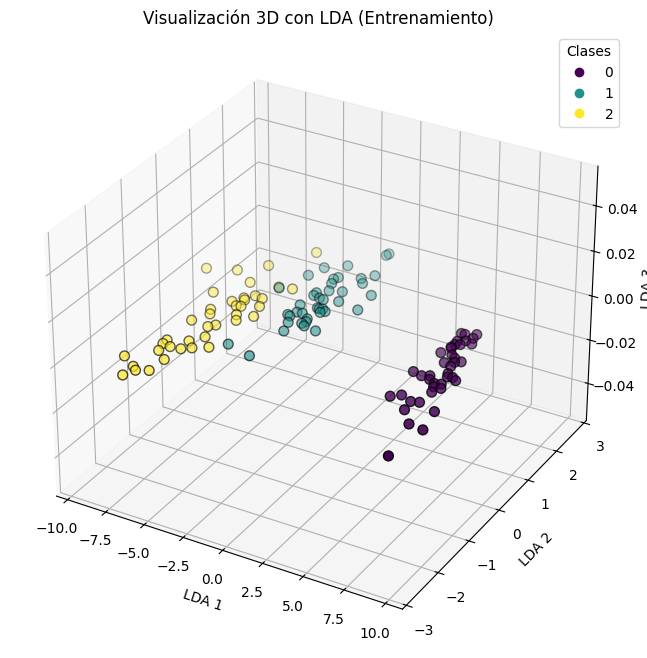

In [ ]:
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_train_scaled, y_train)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_lda[:, 0], X_lda[:, 1],
                    c=y_train, cmap='viridis', s=50, edgecolor='k')

ax.set_xlabel('LDA 1')
ax.set_ylabel('LDA 2')
ax.set_zlabel('LDA 3')
plt.title("Visualización 3D con LDA (Entrenamiento)")
plt.legend(*scatter.legend_elements(), title="Clases")
plt.show()


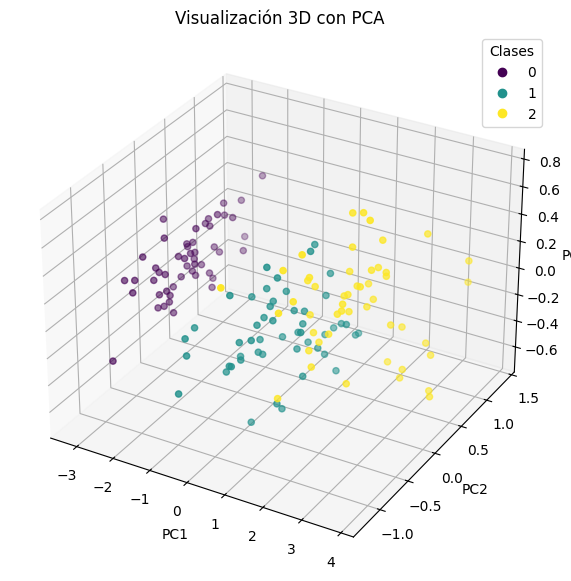

In [ ]:
pca3d = PCA(n_components=3)
X_pca3d = pca3d.fit_transform(X)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca3d[:, 0], X_pca3d[:, 1], X_pca3d[:, 2], c=y, cmap='viridis')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title("Visualización 3D con PCA")
plt.legend(*scatter.legend_elements(), title="Clases")
plt.show()
